In [2]:
#Imorting Libraries
import pandas as pd
from datasets import load_dataset
from datetime import datetime
import ast
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [5]:
#Data loading
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [6]:
#Data CleanUp
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

<Axes: xlabel='count', ylabel='job_location'>

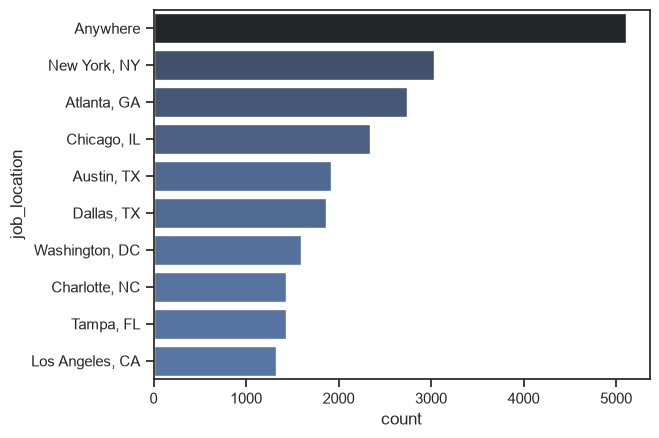

<Axes: xlabel='count', ylabel='job_location'>

Error in callback <function flush_figures at 0x0000024290FD1BC0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# Set the overall visual style to 'ticks' (adds small axis marks, removes background grid)
sns.set_theme(style="ticks")

# Filter for US Data Analyst jobs only and create a clean, independent copy of the data
df_us_da = df[
    (df["job_title_short"] == "Data Analyst")
    & (df["job_country"] == "United States")
].copy()

# Count jobs per location, take the top 10, and convert it to a new DataFrame
counts_by_location = (
    df_us_da["job_location"].value_counts().head(10).to_frame().copy()
)

# Create a horizontal bar plot with a dark-to-blue gradient palette (dark:b_r)
sns.barplot(
    counts_by_location,
    x="count",
    y="job_location",
    hue="count",
    palette="dark:b_r",
    legend=False,
)


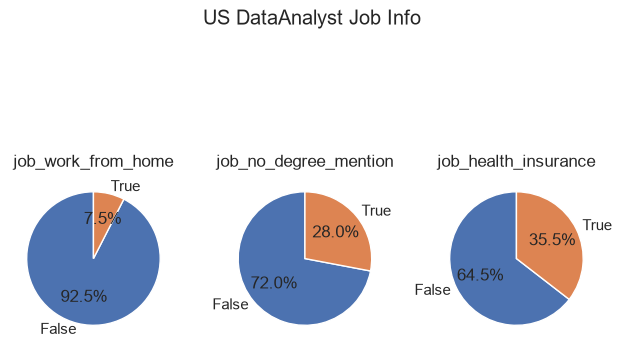

In [6]:
# Create 1 row with 3 side-by-side empty subplots
fig, ax = plt.subplots(1, 3)

# List the specific columns to analyze and plot
to_plot_list = [
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
]

# Loop through columns; 'i' tracks the subplot index, 'to_plot' is the column name
for i, to_plot in enumerate(to_plot_list):
    # Count value frequencies and plot as a pie chart in the current subplot slot (ax[i])
    df_us_da[to_plot].value_counts().plot(
        kind="pie",
        startangle=90,
        autopct="%1.1f%%",
        title=to_plot,
        ax=ax[i],  # 90° rotates start to top; autopct formats percentage text
    )

# Add a single main title above all three pie charts
fig.suptitle("US DataAnalyst Job Info")

# Automatically fix spacing so titles and charts don't overlap
fig.tight_layout()


Text(0.5, 1.0, 'US Top 10 Data Analyst Companies Job Post Counts')

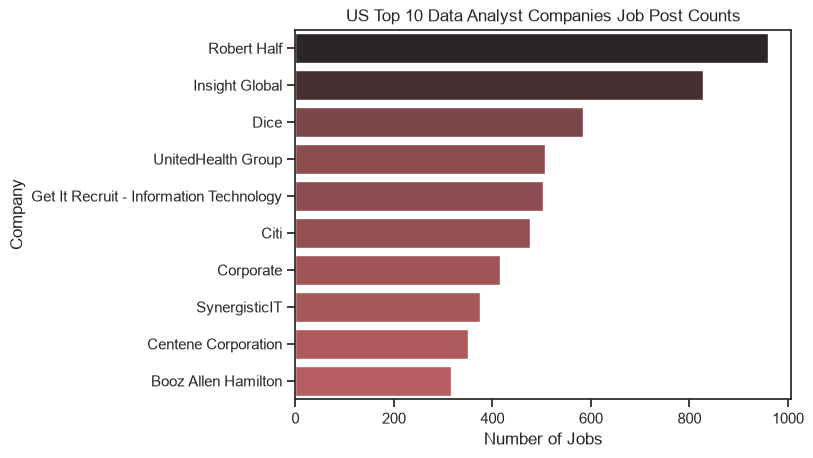

In [7]:
# Count job posts per company, take the top 10, and convert it to a new DataFrame
company_counts = df_us_da["company_name"].value_counts().head(10).to_frame().copy()

# Create horizontal bar plot (x='count', y='company_name') with a dark-to-red gradient palette
sns.barplot(
    company_counts,
    x="count",
    y="company_name",
    hue="count",
    palette="dark:r_r",
    legend=False,
)

# Label the horizontal X-axis
plt.xlabel("Number of Jobs")

# Label the vertical Y-axis
plt.ylabel("Company")

# Add the main title at the top of the chart
plt.title("US Top 10 Data Analyst Companies Job Post Counts")


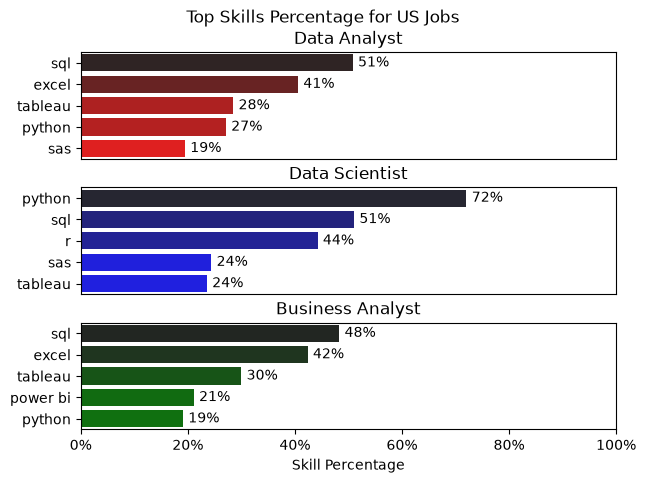

In [7]:
 #To Do: Count job skills per job_title_short for US jobs And Plot it


df_us = df[df['job_country'] == 'United States'].copy()

df_us_exploded = df_us.explode('job_skills')

df_us_skillsCount = df_us_exploded.groupby(['job_skills','job_title_short']).size().reset_index(name = 'skill_counts')

df_us_skillsCount.sort_values(by='skill_counts', ascending=False, inplace=True)


#Total jobs per job_title_short for US jobs

df_total_jobs = df_us['job_title_short'].value_counts().reset_index(name = 'Total Jobs').copy()


df_skills_pct = df_us_skillsCount.merge(df_total_jobs, on='job_title_short', how='left')
df_skills_pct['skill_percentage'] = (df_skills_pct['skill_counts']/df_skills_pct['Total Jobs'] * 100).round(2)
df_skills_pct.sort_values(by='skill_percentage', ascending=False, inplace=True)

# Plotting the top skills percentage for each job title
fig, ax = plt.subplots(3,1)
job_titles = ['Data Analyst', 'Data Scientist', 'Business Analyst']

'''for i,title in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == title].head()
    df_plot.plot(kind = 'barh', x = 'job_skills',y = 'skill_percentage', ax=ax[i], legend=False, title=title)
    ax[i].set_xlabel('Skill Percentage')
    ax[i].set_ylabel('Job Skills')
    ax[i].set_xlim(0, 100)
    ax[i].invert_yaxis()
    ax[i].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))  # Format x-axis as percentage'''

#plotting the top skills percentage for each job title using seaborn
palette_colors = ['dark:r_r', 'dark:b_r', 'dark:g_r']  # Define a list of colors for each job title
for i, title in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == title].head()
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue = 'skill_counts', palette=palette_colors[i], dodge=False, legend=False)
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 100)
    ax[i].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))  # Format x-axis as percentage

    for index,name in enumerate(df_plot['skill_percentage']):
        ax[i].text(name + 1, index, f'{name:.0f}%', va='center')  # Add percentage text to the right of each bar,name + 1 adds a small offset to avoid overlap with the bar,index is used to position the text vertically in line with the bar(name is the skill percentage value for the current bar and index is the position of the bar in the y-axis)

    if i != len(job_titles)-1:
        ax[i].set_xticks([])  # Hide x-axis ticks for all but the last subplot
    if i == len(job_titles)-1:
        ax[i].set_xlabel('Skill Percentage')  # Label x-axis only for the last subplot
fig.suptitle('Top Skills Percentage for US Jobs')
fig.tight_layout(pad = 0.5)



([Text(11.281653225806453, 47.48248012369799, 'sql'),
  Text(11.06209677419355, 39.36486263186588, 'excel'),
  Text(10.891330645161291, 30.138234535698466, 'tableau'),
  Text(10.379032258064518, 27.71848655303383, 'python'),
  Text(11.220665322580647, 20.641565320983748, 'sas')],
 [])

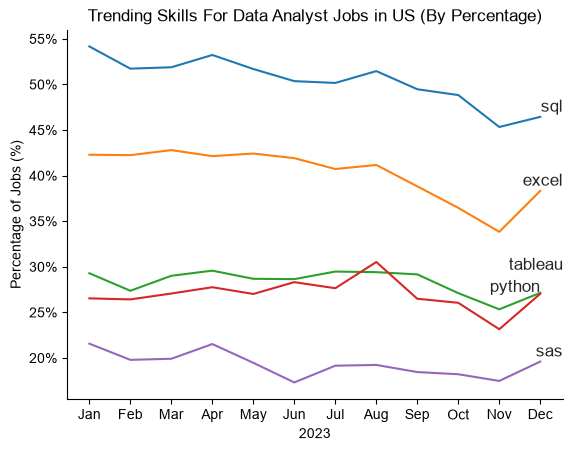

In [10]:
# Trending Skills For Data Analyst Jobs in US (By Percentage)

# Keep only Data Analyst jobs in the US
df_us_da = df_us[df_us['job_title_short'] == 'Data Analyst'].copy()

# Extract month number (1-12) from posting date
df_us_da['month'] = df_us_da['job_posted_date'].dt.month

# Convert each skill list into separate rows
df_us_da_exploded = df_us_da.explode('job_skills')


# Create table: rows = months, columns = skills, values = skill counts
# size() counts the number of rows in each month-skill combination
df_us_da_pivot = df_us_da_exploded.pivot_table(
    index='month',
    columns='job_skills',
    aggfunc='size'
).fillna(0)


# Add a Total row to find the most common skills across the whole year
df_us_da_pivot.loc['Total'] = df_us_da_pivot.sum()

# Sort skill columns by their total count (highest to lowest)
df_us_da_top5 = df_us_da_pivot[
    df_us_da_pivot.loc['Total'].sort_values(ascending=False).index
]

# Remove Total row because we only need monthly data now
df_us_da_top5 = df_us_da_top5.drop('Total')


# Count total Data Analyst job postings in each month
da_totals = df_us_da.groupby('month').size()

# Convert skill counts into percentage of Data Analyst jobs per month
df_us_da_percentage = df_us_da_top5.div(da_totals / 100, axis=0)


# Bring month from index into a normal column
df_us_da_percentage = df_us_da_percentage.reset_index()

# Convert month numbers (1-12) into names (Jan, Feb, Mar...)
df_us_da_percentage['month_name'] = df_us_da_percentage['month'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)

# Make month names the index and remove old month-number column
df_us_da_percentage = (
    df_us_da_percentage
    .set_index('month_name')
    .drop(columns='month')
)


# Select only the top 5 skills for plotting
df_plot = df_us_da_percentage.iloc[:, 0:5]

# Plot monthly percentage trend for each skill
sns.lineplot(
    data=df_plot,
    dashes=False,
    palette='tab10',
    legend=False
)

# Apply clean Seaborn theme
sns.set_theme(style="ticks")

# Remove top and right borders
sns.despine()

plt.title('Trending Skills For Data Analyst Jobs in US (By Percentage)')
plt.ylabel('Percentage of Jobs (%)')
plt.xlabel('2023')

# Display Y-axis values as percentages, e.g. 45%
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:.0f}%')
)


# Store text labels so adjust_text can reposition them later
texts = []

for i, skill in enumerate(df_plot.columns):
    texts.append(
        plt.text(
            11,                    # X position = December
            df_plot.iloc[-1, i],  # Y position = skill's December value
            skill                 # Text = skill name
        )
    )


from adjustText import adjust_text

# Move labels vertically (up/down) to prevent overlapping
adjust_text(texts, only_move={'text': 'y'})

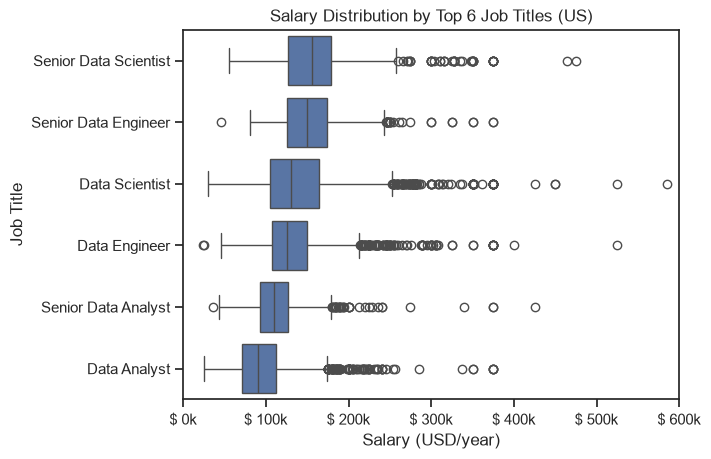

In [ ]:

#US salary comparison for the six most common data job titles.
'''This block filters the dataset to US jobs with reported annual salaries,
 identifies the six most frequent job titles, and compares their salary
 distributions using a box plot. The goal is to visualize how compensation
 varies across the most common roles and to highlight relative pay levels
 between titles in the US market'''

df_US = df[
    (df["job_country"] == "United States")
    & df["salary_year_avg"].notna()
].copy()

top6_job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

df_US = df_US[df_US['job_title_short'].isin(top6_job_titles)]
job_order = df_US.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_US,
    x="salary_year_avg",
    y="job_title_short",
    order=job_order
)
plt.title("Salary Distribution by Top 6 Job Titles (US)")
plt.xlabel("Salary (USD/year)")
plt.ylabel("Job Title")

plt.xlim(0, 600000)
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'$ {x/1000:,.0f}k')
)
plt.show()



In [15]:
highest_paying_skills 

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
...,...,...
ubuntu,0,NaN
unreal,0,NaN
vue.js,0,NaN


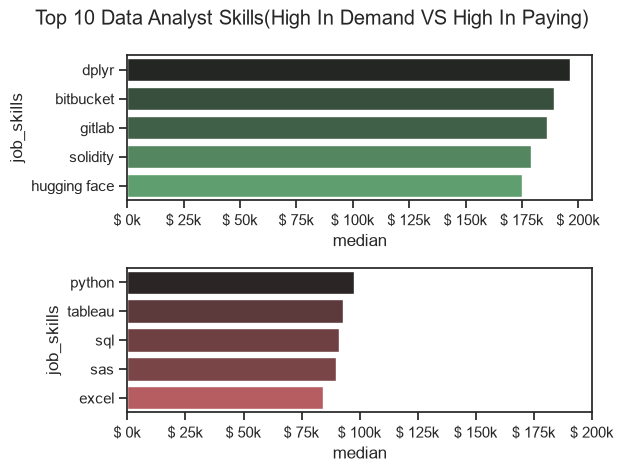

In [ ]:
# Compare highest-paying skills vs highest-demand skills for Data Analyst jobs

# Group by skill and calculate:
# count = number of jobs mentioning the skill
# median = median salary for that skill
highest_demand_skills = (
    df_us_da_exploded.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='count', ascending=False)
)

# Take the 5 most demanded skills, then arrange them by median salary
highest_demand_skills = (
    highest_demand_skills.iloc[0:5]
    .sort_values(by='median', ascending=False)
)

# Group by skill and sort directly by median salary to find highest-paying skills
highest_paying_skills = (
    df_us_da_exploded.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='median', ascending=False)
)

# Create 2 plots vertically:
# ax[0] = top chart, ax[1] = bottom chart
fig, ax = plt.subplots(2, 1)

# Apply Seaborn theme to both plots
sns.set_theme(style='ticks')


# ----- TOP PLOT: Highest Paying Skills -----

sns.barplot(
    data=highest_paying_skills.iloc[0:5],
    x='median',
    y='job_skills',
    hue='median',
    palette='dark:g_r',
    ax=ax[0],                 # Explicitly draw this plot on the FIRST axes
    legend=False
)

# Format x-axis values as salary in thousands: 120000 -> $120k
# We use ax[0].xaxis instead of plt.gca() because we have MULTIPLE axes.
# plt.gca() means "get current axes", which may return whichever subplot is currently active.
# ax[0] directly targets the FIRST subplot, so there is no ambiguity.
ax[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k')
)


# ----- BOTTOM PLOT: Highest Demand Skills -----

sns.barplot(
    data=highest_demand_skills.iloc[0:5],
    x='median',
    y='job_skills',
    hue='median',
    palette='dark:r_r',
    ax=ax[1],                 # Explicitly draw this plot on the SECOND axes
    legend=False
)

# ax[1].xaxis specifically formats the x-axis of the SECOND subplot
ax[1].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k')
)

# Set x-axis range only for the second subplot
ax[1].set_xlim(0, 200000)

# Main title for the complete figure (both subplots)
fig.suptitle('Top 10 Data Analyst Skills (High Paying vs High Demand)')

# Automatically adjust spacing so plots/titles don't overlap
fig.tight_layout()

,count,median
job_skills,,
python,1431,97500.0
tableau,1364,92875.0
sql,2508,91000.0
sas,926,90000.0
excel,1808,84392.0
